# SAM3 Zero-Shot Crack Segmentation on TTD

This notebook is a starting point for running a `SAM3`-style zero-shot experiment on the TACK Tunnel Data (TTD) crack segmentation task.

What is already implemented here:
- TTD split loading
- crack-mask sanitization
- zero-shot evaluation loop
- candidate-mask ranking for crack-like regions
- IoU / F1 / precision / recall summaries
- qualitative visualization

What you still need to plug in:
- the actual `SAM3` package import
- model checkpoint path or model id
- the backend-specific automatic mask generation call


## Suggested Packages

You said you prefer to install packages yourself, so here is the minimal list I recommend before running this notebook:

```bash
pip install numpy pandas pillow matplotlib tqdm opencv-python jupyter
```

Depending on how your `SAM3` implementation is distributed, you will likely also need one of these routes:

1. Official or custom repo route
```bash
pip install -e /path/to/your/sam3/repo
```

2. Hugging Face / Transformers style route
```bash
pip install transformers accelerate safetensors
```

If your SAM3 package has extra CUDA extensions, install those first before opening this notebook.


In [1]:
from pathlib import Path
import json
import math
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display
try:
    import cv2
except ImportError:
    cv2 = None


def find_project_repo_root(start=None):
    env_root = os.environ.get('PROJECT_REPO_ROOT')
    if env_root:
        root = Path(env_root).expanduser().resolve()
        if (root / 'SAM3').exists() and (root / 'TACK_Tunnel_Data').exists():
            return root
        raise FileNotFoundError(
            f'PROJECT_REPO_ROOT does not look like CSCI5527-final: {root}'
        )

    start_path = Path(start or Path.cwd()).resolve()
    candidates = [start_path, *start_path.parents]
    candidates.extend([
        start_path / 'CSCI5527-final',
        start_path.parent / 'CSCI5527-final',
    ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'SAM3').exists() and (candidate / 'TACK_Tunnel_Data').exists():
            return candidate

    raise FileNotFoundError(
        'Could not find the CSCI5527-final repo root. Expected a directory containing '
        "both SAM3/ and TACK_Tunnel_Data/. If needed, set os.environ['PROJECT_REPO_ROOT'] "
        'before running this cell.'
    )


PROJECT_ROOT = find_project_repo_root()
WORKSPACE_ROOT = PROJECT_ROOT.parent
SAM3_ROOT = PROJECT_ROOT / 'SAM3'
SAM3_REPO_ROOT = Path(os.environ.get('SAM3_REPO_ROOT', WORKSPACE_ROOT / 'sam3')).resolve()
OUTPUT_ROOT = SAM3_ROOT / 'outputs' / 'zero_shot'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EXPERIMENT = 'Single-TB'
MAX_SAMPLES = None  # set to an int like 20 for a quick smoke run
SAVE_PRED_MASKS = True

print('Project repo root:', PROJECT_ROOT)
print('SAM3 work root:', SAM3_ROOT)
print('External SAM3 repo root:', SAM3_REPO_ROOT)
print('Output root:', OUTPUT_ROOT)


/users/7/yu001011/csci5527/CSCI5527-final
/users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot


In [2]:
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple


EXPERIMENTS = {
    "Single-TA": {
        "train_files": ["TA_train.csv"],
        "val_files": ["TA_val.csv"],
        "test_files": ["TA_test.csv"],
    },
    "Single-TB": {
        "train_files": ["TB_train.csv"],
        "val_files": ["TB_val.csv"],
        "test_files": ["TB_test.csv"],
    },
    "Single-TC": {
        "train_files": ["TC_train.csv"],
        "val_files": ["TC_val.csv"],
        "test_files": ["TC_test.csv"],
    },
    "Multi-Domain": {
        "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
        "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
        "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"],
    },
    "Shift-TA_TB-to-TC_10pct": {
        "train_files": ["TA_train.csv", "TB_train.csv"],
        "val_files": ["TA_val.csv", "TB_val.csv"],
        "test_files": ["TC_test.csv"],
    },
    "Shift-TA_TC-to-TB_10pct": {
        "train_files": ["TA_train.csv", "TC_train.csv"],
        "val_files": ["TA_val.csv", "TC_val.csv"],
        "test_files": ["TB_test.csv"],
    },
}


@dataclass(frozen=True)
class TTDPaths:
    project_root: Path

    @property
    def dataset_root(self) -> Path:
        return self.project_root / 'TACK_Tunnel_Data'

    @property
    def csv_dir(self) -> Path:
        return self.dataset_root / '2_model_input'

    @property
    def raw_mask_dir(self) -> Path:
        return self.dataset_root / '3_mask'

    @property
    def sanitized_mask_dir(self) -> Path:
        return self.dataset_root / '3_masks_sanitized'


class TTDDatasetBuilder:
    def __init__(self, project_root: str | Path):
        self.paths = TTDPaths(project_root=Path(project_root).resolve())
        self.paths.sanitized_mask_dir.mkdir(parents=True, exist_ok=True)

    def load_experiment(self, experiment_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
        if experiment_name not in EXPERIMENTS:
            raise ValueError(f'Unknown experiment: {experiment_name}')
        cfg = EXPERIMENTS[experiment_name]
        return self.load_csv_data(cfg['train_files'], cfg['val_files'], cfg['test_files'])

    def load_csv_data(
        self,
        train_files: Sequence[str],
        val_files: Sequence[str],
        test_files: Optional[Sequence[str]] = None,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        def _read(files: Iterable[str], is_valid: bool, is_test: bool) -> pd.DataFrame:
            frames = []
            for filename in files:
                csv_path = self.paths.csv_dir / filename
                if not csv_path.exists():
                    continue
                df = pd.read_csv(csv_path)
                df['source_csv'] = filename
                df['is_valid'] = is_valid
                df['is_test'] = is_test
                frames.append(df)
            if not frames:
                return pd.DataFrame()
            return pd.concat(frames, ignore_index=True)

        train_val_df = pd.concat(
            [
                _read(train_files, is_valid=False, is_test=False),
                _read(val_files, is_valid=True, is_test=False),
            ],
            ignore_index=True,
        )
        test_df = _read(test_files, is_valid=False, is_test=True) if test_files else pd.DataFrame()
        return train_val_df, test_df

    def sanitize_masks(self, df: pd.DataFrame, class_pixel_value: int = 40, sanitized_value: int = 1) -> pd.DataFrame:
        image_abs_paths = []
        sanitized_paths = []
        valid_indices = []

        for idx, row in df.iterrows():
            clean_filename = str(row['filename']).split('../')[-1]
            abs_img_path = (self.paths.dataset_root / clean_filename).resolve()
            img_name = abs_img_path.stem
            parts = img_name.rsplit('_', 1)
            mask_name = f"{parts[0]}_fuse_{parts[1]}_1band.png" if len(parts) == 2 else f"{img_name}.png"
            raw_mask_path = self.paths.raw_mask_dir / mask_name
            sanitized_mask_path = self.paths.sanitized_mask_dir / mask_name

            if not raw_mask_path.exists() or not abs_img_path.exists():
                continue

            if not sanitized_mask_path.exists():
                mask_arr = np.array(Image.open(raw_mask_path))
                new_mask = np.zeros_like(mask_arr, dtype=np.uint8)
                if int(row.get('target', 0)) == 1:
                    new_mask[mask_arr == class_pixel_value] = sanitized_value
                Image.fromarray(new_mask).save(sanitized_mask_path)

            image_abs_paths.append(str(abs_img_path))
            sanitized_paths.append(str(sanitized_mask_path))
            valid_indices.append(idx)

        out = df.iloc[valid_indices].copy()
        out['image_abs_path'] = image_abs_paths
        out['mask_path_sanitized'] = sanitized_paths
        return out

    def build_records(self, experiment_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
        train_val_df, test_df = self.load_experiment(experiment_name)
        train_val_ready = self.sanitize_masks(train_val_df)
        test_ready = self.sanitize_masks(test_df)
        return train_val_ready, test_ready


def _binarize(mask: np.ndarray) -> np.ndarray:
    return (mask > 0).astype(np.uint8)


def confusion_stats(pred_mask: np.ndarray, true_mask: np.ndarray):
    pred = _binarize(pred_mask)
    true = _binarize(true_mask)
    tp = float(((pred == 1) & (true == 1)).sum())
    fp = float(((pred == 1) & (true == 0)).sum())
    fn = float(((pred == 0) & (true == 1)).sum())
    tn = float(((pred == 0) & (true == 0)).sum())
    return {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}


def iou(pred_mask: np.ndarray, true_mask: np.ndarray, smooth: float = 1e-6) -> float:
    stats = confusion_stats(pred_mask, true_mask)
    return (stats['tp'] + smooth) / (stats['tp'] + stats['fp'] + stats['fn'] + smooth)


def precision(pred_mask: np.ndarray, true_mask: np.ndarray, smooth: float = 1e-6) -> float:
    stats = confusion_stats(pred_mask, true_mask)
    return (stats['tp'] + smooth) / (stats['tp'] + stats['fp'] + smooth)


def recall(pred_mask: np.ndarray, true_mask: np.ndarray, smooth: float = 1e-6) -> float:
    stats = confusion_stats(pred_mask, true_mask)
    return (stats['tp'] + smooth) / (stats['tp'] + stats['fn'] + smooth)


def f1(pred_mask: np.ndarray, true_mask: np.ndarray, smooth: float = 1e-6) -> float:
    p = precision(pred_mask, true_mask, smooth=smooth)
    r = recall(pred_mask, true_mask, smooth=smooth)
    return 2.0 * (p * r) / (p + r + smooth)


builder = TTDDatasetBuilder(PROJECT_ROOT)
train_val_df, test_df = builder.build_records(EXPERIMENT)

if MAX_SAMPLES is not None:
    test_df = test_df.head(MAX_SAMPLES).copy()

print('train_val rows:', len(train_val_df))
print('test rows:', len(test_df))
display(test_df.head())



train_val rows: 424
test rows: 48


,filename,label,target,source_csv,is_valid,is_test,image_abs_path,mask_path_sanitized
0,../3_img/TB_Camera7_000012_E.png,no_crack,0,TB_test.csv,False,True,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...
1,../3_img/TB_Camera3_001107_H.png,no_crack,0,TB_test.csv,False,True,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...
2,../3_img/TB_Camera4_000334_N.png,no_crack,0,TB_test.csv,False,True,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...
3,../3_img/TB_Camera5_000894_E.png,no_crack,0,TB_test.csv,False,True,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...
4,../3_img/TB_Camera9_000558_N.png,no_crack,0,TB_test.csv,False,True,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...


In [3]:
def load_rgb_image(image_path):
    return np.array(Image.open(image_path).convert('RGB'))


def load_binary_mask(mask_path):
    return (np.array(Image.open(mask_path)) > 0).astype(np.uint8)


def resize_mask_to_shape(mask, shape_hw):
    h, w = shape_hw
    pil_mask = Image.fromarray((mask > 0).astype(np.uint8) * 255)
    pil_mask = pil_mask.resize((w, h), Image.NEAREST)
    return (np.array(pil_mask) > 0).astype(np.uint8)


def compute_mask_features(mask):
    mask = (mask > 0).astype(np.uint8)
    area = float(mask.sum())
    h, w = mask.shape
    area_ratio = area / float(h * w)

    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return {
            'area': 0.0,
            'area_ratio': 0.0,
            'bbox_h': 0.0,
            'bbox_w': 0.0,
            'aspect_ratio': 0.0,
            'thinness': 0.0,
            'elongation_score': 0.0,
        }

    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    bbox_h = float(y1 - y0 + 1)
    bbox_w = float(x1 - x0 + 1)
    aspect_ratio = max(bbox_h, bbox_w) / max(1.0, min(bbox_h, bbox_w))
    bbox_area = max(1.0, bbox_h * bbox_w)
    thinness = area / bbox_area

    return {
        'area': area,
        'area_ratio': area_ratio,
        'bbox_h': bbox_h,
        'bbox_w': bbox_w,
        'aspect_ratio': aspect_ratio,
        'thinness': thinness,
        'elongation_score': min(aspect_ratio / 20.0, 1.0),
    }


def score_crack_candidate(mask):
    feats = compute_mask_features(mask)
    if feats['area'] <= 0:
        return -1e9, feats

    area_term = 1.0 - min(feats['area_ratio'] / 0.15, 1.0)
    thin_term = 1.0 - min(feats['thinness'], 1.0)
    elongation_term = feats['elongation_score']

    score = (0.35 * area_term) + (0.35 * thin_term) + (0.30 * elongation_term)
    return score, feats


def select_best_crack_mask(candidate_masks, image_shape_hw):
    if not candidate_masks:
        return np.zeros(image_shape_hw, dtype=np.uint8), {'reason': 'no_candidates'}

    ranked = []
    for idx, candidate in enumerate(candidate_masks):
        raw_mask = candidate['segmentation']
        mask = resize_mask_to_shape(raw_mask, image_shape_hw)
        score, feats = score_crack_candidate(mask)
        ranked.append({
            'index': idx,
            'mask': mask,
            'score': score,
            'features': feats,
            'raw': candidate,
        })

    ranked = sorted(ranked, key=lambda x: x['score'], reverse=True)
    best = ranked[0]
    meta = {
        'selected_index': best['index'],
        'selected_score': best['score'],
        'selected_features': best['features'],
        'num_candidates': len(ranked),
    }
    return best['mask'].astype(np.uint8), meta


def build_overlap_rgb(pred_mask, true_mask):
    pred_mask = (pred_mask > 0).astype(np.uint8)
    true_mask = (true_mask > 0).astype(np.uint8)
    overlay = np.zeros((true_mask.shape[0], true_mask.shape[1], 3), dtype=np.float32)
    overlay[(pred_mask == 1) & (true_mask == 1)] = [0.0, 1.0, 0.0]
    overlay[(pred_mask == 1) & (true_mask == 0)] = [1.0, 1.0, 0.0]
    overlay[(pred_mask == 0) & (true_mask == 1)] = [1.0, 0.0, 0.0]
    return overlay


def show_prediction_triplet(image, true_mask, pred_mask, title='sample'):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(image)
    axes[0].set_title(f'{title}: image')
    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title('ground truth')
    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title('prediction')
    axes[3].imshow(build_overlap_rgb(pred_mask, true_mask))
    axes[3].set_title('overlap')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## SAM3 Backend Adapter

This is the only part that depends on the exact `SAM3` library you choose.

The rest of the notebook expects a backend object with a method:

```python
candidate_masks = backend.generate_masks(image_rgb)
```

where `candidate_masks` is a list of dictionaries and each dictionary contains at least:

```python
{
    'segmentation': np.ndarray,  # binary mask
}|
```

If your SAM3 package returns masks in another format, convert them inside the adapter cell below.


In [4]:
import torch
from torchvision.transforms import v2
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.model.vitdet import Mlp as Sam3VitMlp

SAM3_MODEL_ID = None
SAM3_CHECKPOINT = None
SAM3_DEVICE = 'cuda'
SAM3_PROMPT_TEXT = 'crack'
SAM3_PROMPT_CANDIDATES = [
    'crack',
    'surface crack',
    'concrete crack',
    'tunnel wall crack',
    'thin crack',
]
SAM3_CONFIDENCE_THRESHOLD = 0.05
SAM3_SMOKE_TEST_INDEX = 0
SAM3_MODEL_DTYPE = torch.float32


def _normalize_prompt_candidates(prompt_text, prompt_candidates=None):
    candidates = []
    if prompt_text is not None:
        candidates.append(prompt_text)
    if prompt_candidates is not None:
        candidates.extend(prompt_candidates)

    normalized = []
    seen = set()
    for prompt in candidates:
        prompt = str(prompt).strip()
        if not prompt or prompt in seen:
            continue
        normalized.append(prompt)
        seen.add(prompt)
    return normalized


def _to_numpy_binary_mask(mask_like):
    if hasattr(mask_like, 'detach'):
        arr = mask_like.detach().float().cpu().numpy()
    else:
        arr = np.asarray(mask_like)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f'Expected a 2D mask after squeeze, got shape={arr.shape}')
    return (arr > 0).astype(np.uint8)


def _to_float_score(score_like):
    if hasattr(score_like, 'detach'):
        score_like = score_like.detach().float().cpu().numpy()
    score_arr = np.asarray(score_like).reshape(-1)
    if len(score_arr) == 0:
        return float('nan')
    return float(score_arr[0])


class SAM3AutoMaskBackend:
    def __init__(
        self,
        model_id=None,
        checkpoint_path=None,
        device='cuda',
        prompt_text='crack',
        prompt_candidates=None,
        confidence_threshold=0.05,
        model_dtype=torch.float32,
    ):
        self.model_id = model_id
        self.checkpoint_path = checkpoint_path
        self.device = device
        self.prompt_text = prompt_text
        self.prompt_candidates = _normalize_prompt_candidates(prompt_text, prompt_candidates)
        self.confidence_threshold = confidence_threshold
        self.model_dtype = model_dtype

        if checkpoint_path is not None:
            self.model = build_sam3_image_model(
                checkpoint_path=str(checkpoint_path),
                device=device,
            )
        else:
            self.model = build_sam3_image_model(device=device)

        self.model = self.model.to(device=self.device, dtype=self.model_dtype)
        self.model.eval()

        first_param = next(self.model.parameters())
        print('SAM3 model first param dtype:', first_param.dtype)
        print('SAM3 model first param device:', first_param.device)
        print('SAM3 confidence threshold:', self.confidence_threshold)
        print('SAM3 prompt candidates:', self.prompt_candidates)

        residual_float32 = []
        for name, param in self.model.named_parameters():
            if param.dtype == torch.float32:
                residual_float32.append(name)
                if len(residual_float32) >= 10:
                    break
        print('First few float32 params after cast:', residual_float32 if residual_float32 else 'none')

        self._patch_vit_mlp_dtype()
        self._patch_decoder_ffn_dtype()
        self.processor = Sam3Processor(
            self.model,
            device=self.device,
            confidence_threshold=self.confidence_threshold,
        )
        self.image_transform = v2.Compose(
            [
                v2.ToDtype(torch.uint8, scale=True),
                v2.Resize(size=(self.processor.resolution, self.processor.resolution)),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ]
        )

    def _patch_vit_mlp_dtype(self):
        original_forward = Sam3VitMlp.forward

        def _patched_forward(module, x):
            fc1_dtype = module.fc1.weight.dtype
            if x.dtype != fc1_dtype:
                x = x.to(fc1_dtype)
            x = module.fc1(x)
            x = module.act(x)
            x = module.drop1(x)
            x = module.norm(x)
            fc2_dtype = module.fc2.weight.dtype
            if x.dtype != fc2_dtype:
                x = x.to(fc2_dtype)
            x = module.fc2(x)
            x = module.drop2(x)
            return x

        Sam3VitMlp.forward = _patched_forward
        self._original_vit_mlp_forward = original_forward
        print('Patched vitdet.Mlp.forward dtype guards')

    def _patch_decoder_ffn_dtype(self):
        decoder = self.model.transformer.decoder
        patched_layers = 0

        def _make_patched_forward_ffn(layer):
            def _patched_forward_ffn(tgt):
                target_dtype = layer.linear1.weight.dtype
                if tgt.dtype != target_dtype:
                    tgt = tgt.to(target_dtype)
                with torch.amp.autocast(device_type='cuda', enabled=False):
                    tgt2 = layer.linear2(layer.dropout3(layer.activation(layer.linear1(tgt))))
                    tgt = tgt + layer.dropout4(tgt2)
                    tgt = layer.norm3(tgt)
                return tgt

            return _patched_forward_ffn

        for layer in decoder.layers:
            layer.forward_ffn = _make_patched_forward_ffn(layer)
            patched_layers += 1

        print('Patched decoder forward_ffn dtype guards on layers:', patched_layers)

    @torch.inference_mode()
    def set_image_state(self, image_rgb):
        image_pil = Image.fromarray(image_rgb)
        width, height = image_pil.size
        image = v2.functional.to_image(image_pil).to(self.device)
        image = self.image_transform(image).unsqueeze(0)
        image = image.to(dtype=self.model_dtype)
        state = {
            'original_height': height,
            'original_width': width,
        }
        state['backbone_out'] = self.model.backbone.forward_image(image)
        return state

    @torch.inference_mode()
    def _run_prompt(self, state, prompt):
        self.processor.reset_all_prompts(state)
        output = self.processor.set_text_prompt(state=state, prompt=prompt)
        masks = output.get('masks', [])
        boxes = output.get('boxes', [])
        scores = output.get('scores', [])

        candidate_masks = []
        for idx, mask_like in enumerate(masks):
            candidate_masks.append(
                {
                    'segmentation': _to_numpy_binary_mask(mask_like),
                    'score': _to_float_score(scores[idx]) if idx < len(scores) else float('nan'),
                    'box': None if idx >= len(boxes) else boxes[idx].detach().cpu().numpy(),
                    'prompt_text': prompt,
                    'index': idx,
                }
            )

        finite_scores = [candidate['score'] for candidate in candidate_masks if np.isfinite(candidate['score'])]
        prompt_meta = {
            'prompt_text': prompt,
            'num_candidates': len(candidate_masks),
            'max_model_score': max(finite_scores) if finite_scores else math.nan,
        }
        return candidate_masks, prompt_meta

    @torch.inference_mode()
    def generate_masks(self, image_rgb, prompt_text=None, prompt_candidates=None):
        prompts = _normalize_prompt_candidates(
            prompt_text if prompt_text is not None else self.prompt_text,
            prompt_candidates if prompt_candidates is not None else self.prompt_candidates,
        )
        state = self.set_image_state(image_rgb)
        candidate_masks = []
        for prompt in prompts:
            prompt_masks, _ = self._run_prompt(state, prompt)
            candidate_masks.extend(prompt_masks)

        candidate_masks = sorted(candidate_masks, key=lambda candidate: candidate['score'], reverse=True)
        for idx, candidate in enumerate(candidate_masks):
            candidate['index'] = idx
        return candidate_masks

    @torch.inference_mode()
    def prompt_sweep(self, image_rgb, prompt_text=None, prompt_candidates=None):
        prompts = _normalize_prompt_candidates(
            prompt_text if prompt_text is not None else self.prompt_text,
            prompt_candidates if prompt_candidates is not None else self.prompt_candidates,
        )
        state = self.set_image_state(image_rgb)
        prompt_rows = []
        for prompt in prompts:
            _, prompt_meta = self._run_prompt(state, prompt)
            prompt_rows.append(prompt_meta)

        prompt_df = pd.DataFrame(prompt_rows)
        if len(prompt_df):
            prompt_df = prompt_df.sort_values(
                ['num_candidates', 'max_model_score', 'prompt_text'],
                ascending=[False, False, True],
            ).reset_index(drop=True)
        return prompt_df


backend = SAM3AutoMaskBackend(
    model_id=SAM3_MODEL_ID,
    checkpoint_path=SAM3_CHECKPOINT,
    device=SAM3_DEVICE,
    prompt_text=SAM3_PROMPT_TEXT,
    prompt_candidates=SAM3_PROMPT_CANDIDATES,
    confidence_threshold=SAM3_CONFIDENCE_THRESHOLD,
    model_dtype=SAM3_MODEL_DTYPE,
)


/users/7/yu001011/csci5527/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/users/7/yu001011/csci5527/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


SAM3 model first param dtype: torch.float32
SAM3 model first param device: cuda:0
SAM3 confidence threshold: 0.05
SAM3 prompt candidates: ['crack', 'surface crack', 'concrete crack', 'tunnel wall crack', 'thin crack']
First few float32 params after cast: ['backbone.vision_backbone.trunk.pos_embed', 'backbone.vision_backbone.trunk.patch_embed.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.bias', 'backbone.vision_backbone.trunk.blocks.0.norm2.weight', 'backbone.vision_backbone.trunk.blocks.0.norm2.bias']
Patched vitdet.Mlp.forward dtype guards
Patched decoder forward_ffn dtype guards on layers: 6


/users/7/yu001011/csci5527/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1370: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  return t.to(


## Dtype Debug

Run this cell right after the backend cell if you still see dtype mismatch errors. It helps confirm whether the model and the image tensor are really using the same dtype.


In [5]:
first_param = next(backend.model.parameters())
print('model first param dtype:', first_param.dtype)
print('model first param device:', first_param.device)
float32_params = []
for name, param in backend.model.named_parameters():
    if param.dtype == torch.float32:
        float32_params.append(name)
        if len(float32_params) >= 10:
            break
print('first few float32 params:', float32_params if float32_params else 'none')
print('backend class:', type(backend).__name__)
print('backend confidence threshold:', backend.confidence_threshold)
print('backend prompt candidates:', backend.prompt_candidates)
sample_row = test_df.iloc[SAM3_SMOKE_TEST_INDEX]
image_rgb = load_rgb_image(sample_row['image_abs_path'])
image_pil = Image.fromarray(image_rgb)
image_tensor = v2.functional.to_image(image_pil).to(backend.device)
image_tensor = backend.image_transform(image_tensor).unsqueeze(0)
image_tensor = image_tensor.to(dtype=backend.model_dtype)
print('debug image tensor dtype:', image_tensor.dtype)
print('debug image tensor device:', image_tensor.device)
print('decoder ffn patched:', hasattr(backend, '_patch_decoder_ffn_dtype'))
print('vit mlp patched:', hasattr(backend, '_patch_vit_mlp_dtype'))


model first param dtype: torch.float32
model first param device: cuda:0
first few float32 params: ['backbone.vision_backbone.trunk.pos_embed', 'backbone.vision_backbone.trunk.patch_embed.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.bias', 'backbone.vision_backbone.trunk.blocks.0.norm2.weight', 'backbone.vision_backbone.trunk.blocks.0.norm2.bias']
backend class: SAM3AutoMaskBackend
backend confidence threshold: 0.05
backend prompt candidates: ['crack', 'surface crack', 'concrete crack', 'tunnel wall crack', 'thin crack']
debug image tensor dtype: torch.float32
debug image tensor device: cuda:0
decoder ffn patched: True
vit mlp patched: True


sample file: TB_Camera7_000012_E.png


,prompt_text,num_candidates,max_model_score
0,crack,31,0.126345
1,thin crack,7,0.097880
2,concrete crack,2,0.080845
3,surface crack,0,NaN
4,tunnel wall crack,0,NaN


num candidate masks across prompts: 40
selected meta: {'selected_index': 14, 'selected_score': 0.8930429882511717, 'selected_features': {'area': 2639.0, 'area_ratio': 0.010066986083984375, 'bbox_h': 503.0, 'bbox_w': 22.0, 'aspect_ratio': 22.863636363636363, 'thinness': 0.23847822157961324, 'elongation_score': 1.0}, 'num_candidates': 40, 'selected_prompt': 'thin crack', 'selected_model_score': 0.06821983307600021}


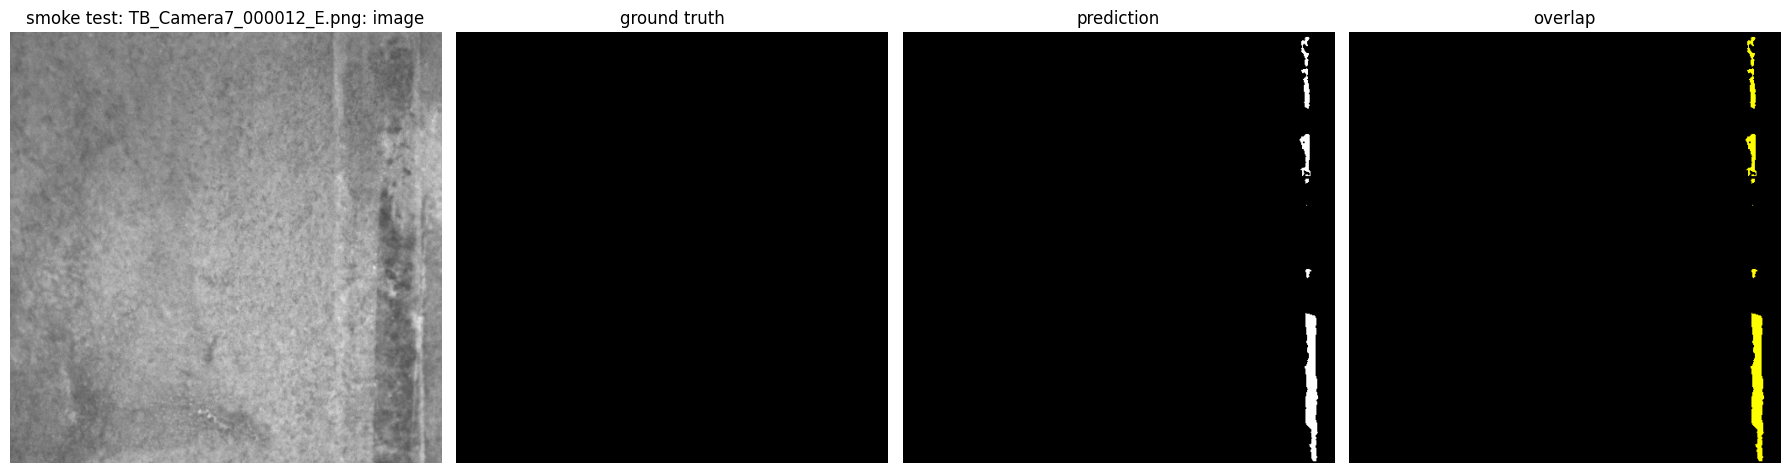

In [6]:
sample_row = test_df.iloc[SAM3_SMOKE_TEST_INDEX]
image_rgb = load_rgb_image(sample_row['image_abs_path'])
gt_mask = load_binary_mask(sample_row['mask_path_sanitized'])

prompt_diagnostics = backend.prompt_sweep(image_rgb)
print('sample file:', Path(sample_row['image_abs_path']).name)
display(prompt_diagnostics)

candidate_masks = backend.generate_masks(image_rgb)
print('num candidate masks across prompts:', len(candidate_masks))

if candidate_masks:
    pred_mask, smoke_meta = select_best_crack_mask(candidate_masks, gt_mask.shape)
    selected_idx = smoke_meta.get('selected_index')
    if selected_idx is not None and selected_idx < len(candidate_masks):
        smoke_meta['selected_prompt'] = candidate_masks[selected_idx].get('prompt_text')
        smoke_meta['selected_model_score'] = candidate_masks[selected_idx].get('score')
    print('selected meta:', smoke_meta)
    show_prediction_triplet(
        image_rgb,
        gt_mask,
        pred_mask,
        title=f"smoke test: {Path(sample_row['image_abs_path']).name}",
    )
else:
    print('No masks were returned by SAM3 for any configured prompt.')


In [7]:
results = []
pred_dir = OUTPUT_ROOT / f'{EXPERIMENT}_pred_masks'
pred_dir.mkdir(parents=True, exist_ok=True)

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    image_path = Path(row['image_abs_path'])
    gt_mask_path = Path(row['mask_path_sanitized'])

    image_rgb = load_rgb_image(image_path)
    gt_mask = load_binary_mask(gt_mask_path)

    candidate_masks = backend.generate_masks(image_rgb)
    pred_mask, selection_meta = select_best_crack_mask(candidate_masks, gt_mask.shape)

    selected_prompt = None
    selected_model_score = math.nan
    selected_idx = selection_meta.get('selected_index')
    if selected_idx is not None and selected_idx < len(candidate_masks):
        selected_candidate = candidate_masks[selected_idx]
        selected_prompt = selected_candidate.get('prompt_text')
        selected_model_score = selected_candidate.get('score', math.nan)

    row_result = {
        'image_path': str(image_path),
        'mask_path': str(gt_mask_path),
        'label': row.get('label', None),
        'target': int(row.get('target', 0)),
        'prompt_text': SAM3_PROMPT_TEXT,
        'prompt_candidates': '|'.join(backend.prompt_candidates),
        'confidence_threshold': backend.confidence_threshold,
        'selected_prompt': selected_prompt,
        'selected_model_score': selected_model_score,
        'iou': iou(pred_mask, gt_mask),
        'f1': f1(pred_mask, gt_mask),
        'precision': precision(pred_mask, gt_mask),
        'recall': recall(pred_mask, gt_mask),
        'num_candidates': selection_meta.get('num_candidates', 0),
        'selected_score': selection_meta.get('selected_score', None),
        'selected_index': selected_idx,
    }

    if SAVE_PRED_MASKS:
        pred_path = pred_dir / f'{image_path.stem}_pred.png'
        Image.fromarray((pred_mask * 255).astype(np.uint8)).save(pred_path)
        row_result['pred_mask_path'] = str(pred_path)

    results.append(row_result)

results_df = pd.DataFrame(results)
results_csv = OUTPUT_ROOT / f'{EXPERIMENT}_sam3_zero_shot_results.csv'
results_df.to_csv(results_csv, index=False)

print('saved:', results_csv)
display(results_df.head())


  0%|          | 0/48 [00:00<?, ?it/s]

saved: /users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot/Single-TB_sam3_zero_shot_results.csv


,image_path,mask_path,label,target,prompt_text,prompt_candidates,confidence_threshold,selected_prompt,selected_model_score,iou,f1,precision,recall,num_candidates,selected_score,selected_index,pred_mask_path
0,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,no_crack,0,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,thin crack,0.068220,3.789314e-10,7.578621e-10,3.789314e-10,1.0,40,0.893043,14.0,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
1,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,no_crack,0,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.064998,7.518797e-09,1.503758e-08,7.518797e-09,1.0,12,0.541435,5.0,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
2,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,no_crack,0,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.051436,6.868132e-10,1.373625e-09,6.868132e-10,1.0,9,0.595110,7.0,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
3,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,no_crack,0,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.051986,8.291874e-11,1.658373e-10,8.291874e-11,1.0,2,0.578189,0.0,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
4,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,no_crack,0,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,thin crack,0.102878,1.834189e-10,3.668375e-10,1.834189e-10,1.0,59,0.732239,5.0,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...


In [8]:
selected_prompt_mode = results_df['selected_prompt'].dropna().mode()
top_selected_prompt = selected_prompt_mode.iloc[0] if len(selected_prompt_mode) else None

summary = pd.DataFrame([
    {
        'experiment': EXPERIMENT,
        'num_samples': len(results_df),
        'prompt_text': SAM3_PROMPT_TEXT,
        'prompt_candidates': '|'.join(backend.prompt_candidates),
        'confidence_threshold': backend.confidence_threshold,
        'top_selected_prompt': top_selected_prompt,
        'mean_iou': results_df['iou'].mean() if len(results_df) else math.nan,
        'mean_f1': results_df['f1'].mean() if len(results_df) else math.nan,
        'mean_precision': results_df['precision'].mean() if len(results_df) else math.nan,
        'mean_recall': results_df['recall'].mean() if len(results_df) else math.nan,
        'mean_num_candidates': results_df['num_candidates'].mean() if len(results_df) else math.nan,
        'mean_selected_model_score': results_df['selected_model_score'].mean() if len(results_df) else math.nan,
    }
])

summary_json = OUTPUT_ROOT / f'{EXPERIMENT}_sam3_zero_shot_summary.json'
summary.to_json(summary_json, orient='records', indent=2)

display(summary)
print('saved:', summary_json)

baseline_compatible_summary = pd.DataFrame([
    {
        'Experiment': EXPERIMENT,
        'Model': 'SAM3_zero_shot',
        'Prompt': SAM3_PROMPT_TEXT,
        'PromptCandidates': '|'.join(backend.prompt_candidates),
        'ConfidenceThreshold': backend.confidence_threshold,
        'Top_Selected_Prompt': top_selected_prompt,
        'Test_IoU': results_df['iou'].mean() if len(results_df) else math.nan,
        'Test_F1': results_df['f1'].mean() if len(results_df) else math.nan,
        'Test_Prec': results_df['precision'].mean() if len(results_df) else math.nan,
        'Test_Recall': results_df['recall'].mean() if len(results_df) else math.nan,
        'Num_Test': len(results_df),
        'Mean_Num_Candidates': results_df['num_candidates'].mean() if len(results_df) else math.nan,
        'Mean_Selected_Model_Score': results_df['selected_model_score'].mean() if len(results_df) else math.nan,
        'Per_Image_Results_CSV': str(results_csv),
    }
])

baseline_summary_csv = OUTPUT_ROOT / f'{EXPERIMENT}_sam3_zero_shot_baseline_compatible_summary.csv'
baseline_compatible_summary.to_csv(baseline_summary_csv, index=False)

print('saved:', baseline_summary_csv)
display(baseline_compatible_summary)


,experiment,num_samples,prompt_text,prompt_candidates,confidence_threshold,top_selected_prompt,mean_iou,mean_f1,mean_precision,mean_recall,mean_num_candidates,mean_selected_model_score
0,Single-TB,48,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.148694,0.160389,0.178178,0.523134,36.5625,0.067105


saved: /users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot/Single-TB_sam3_zero_shot_summary.json
saved: /users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot/Single-TB_sam3_zero_shot_baseline_compatible_summary.csv


,Experiment,Model,Prompt,PromptCandidates,ConfidenceThreshold,Top_Selected_Prompt,Test_IoU,Test_F1,Test_Prec,Test_Recall,Num_Test,Mean_Num_Candidates,Mean_Selected_Model_Score,Per_Image_Results_CSV
0,Single-TB,SAM3_zero_shot,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.148694,0.160389,0.178178,0.523134,48,36.5625,0.067105,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...


Best sample: TB_Camera9_000356_G.png IoU= 1.0
Worst sample: TB_Camera4_000034_L.png IoU= 0.0


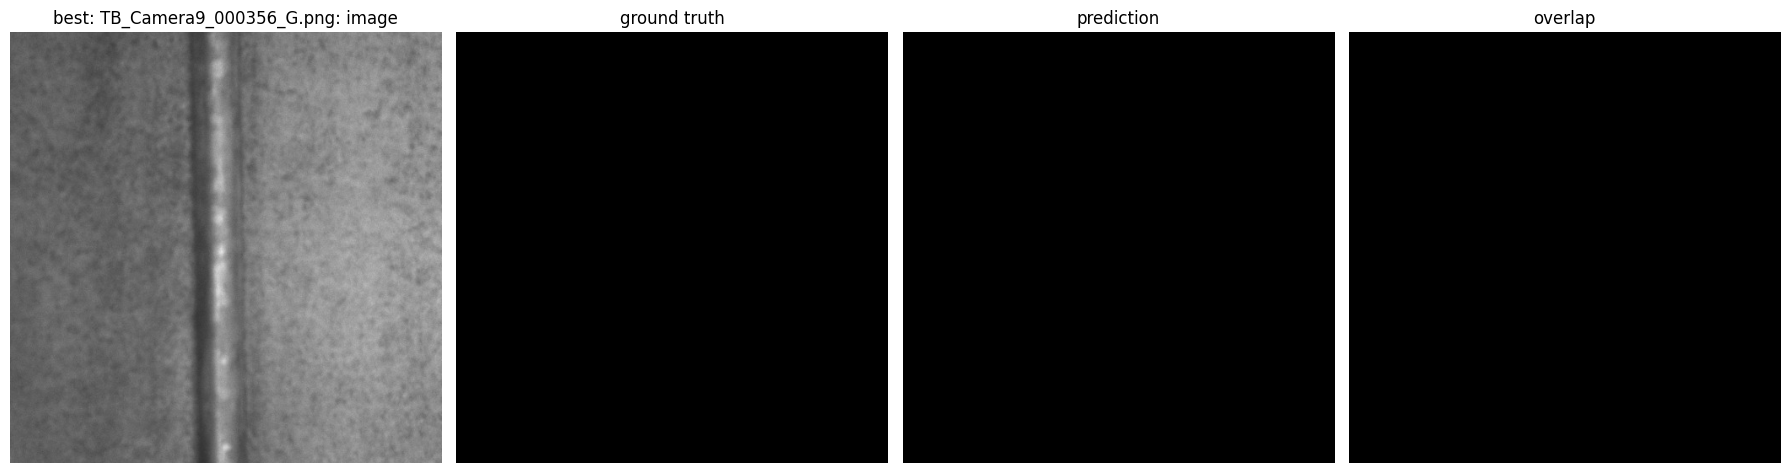

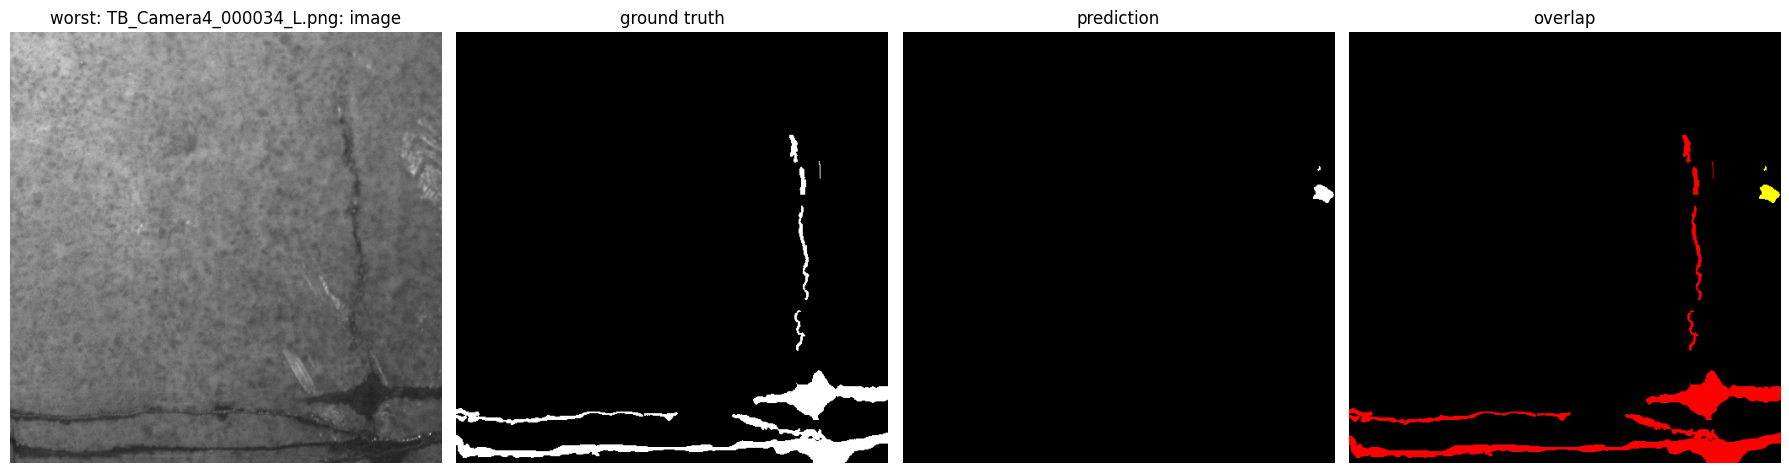

In [9]:
if len(results_df):
    best_row = results_df.sort_values('iou', ascending=False).iloc[0]
    worst_row = results_df.sort_values('iou', ascending=True).iloc[0]

    print('Best sample:', Path(best_row['image_path']).name, 'IoU=', round(float(best_row['iou']), 4))
    print('Worst sample:', Path(worst_row['image_path']).name, 'IoU=', round(float(worst_row['iou']), 4))

    for tag, sample_row in [('best', best_row), ('worst', worst_row)]:
        image_rgb = load_rgb_image(sample_row['image_path'])
        gt_mask = load_binary_mask(sample_row['mask_path'])
        pred_mask = load_binary_mask(sample_row['pred_mask_path'])
        sample_name = Path(sample_row['image_path']).name
        show_prediction_triplet(image_rgb, gt_mask, pred_mask, title=f'{tag}: {sample_name}')


## Empty-Prediction Diagnostics

Use this section to verify whether the current SAM3 zero-shot run is mostly returning empty masks.


In [10]:
if len(results_df) == 0:
    print('results_df is empty. Run the zero-shot evaluation cell first.')
else:
    diagnostics_df = results_df.copy()
    diagnostics_df['num_candidates'] = diagnostics_df['num_candidates'].fillna(0)
    diagnostics_df['is_empty_prediction'] = diagnostics_df['num_candidates'] <= 0
    diagnostics_df['target_name'] = diagnostics_df['target'].map({1: 'crack', 0: 'no_crack'}).fillna('unknown')

    print('Candidate count distribution:')
    display(diagnostics_df['num_candidates'].value_counts(dropna=False).sort_index())

    empty_ratio = diagnostics_df['is_empty_prediction'].mean()
    print('Empty-prediction ratio:', round(float(empty_ratio), 4))

    by_target = diagnostics_df.groupby('target_name').agg(
        num_images=('target', 'size'),
        empty_prediction_ratio=('is_empty_prediction', 'mean'),
        mean_iou=('iou', 'mean'),
        mean_f1=('f1', 'mean'),
        mean_precision=('precision', 'mean'),
        mean_recall=('recall', 'mean'),
        mean_num_candidates=('num_candidates', 'mean'),
        mean_selected_model_score=('selected_model_score', 'mean'),
    ).reset_index()

    print('Metrics by target label:')
    display(by_target)

    if 'selected_prompt' in diagnostics_df.columns:
        print('Selected prompt distribution:')
        display(diagnostics_df['selected_prompt'].fillna('none').value_counts(dropna=False))

    if 'selected_score' in diagnostics_df.columns:
        print('Selected score summary:')
        display(diagnostics_df['selected_score'].describe(include='all'))


Candidate count distribution:


num_candidates
0      7
1      2
2      3
3      4
4      2
5      1
6      1
7      1
8      1
9      1
12     2
13     2
14     1
15     1
17     1
19     2
21     2
24     1
29     1
31     1
40     1
47     1
56     1
59     1
79     1
85     1
118    1
132    1
142    1
312    1
362    1
Name: count, dtype: int64

Empty-prediction ratio: 0.1458
Metrics by target label:


,target_name,num_images,empty_prediction_ratio,mean_iou,mean_f1,mean_precision,mean_recall,mean_num_candidates,mean_selected_model_score
0,crack,24,0.041667,0.047387,0.070778,0.106355,0.087935,55.583333,0.063433
1,no_crack,24,0.250000,0.250000,0.250000,0.250000,0.958333,17.541667,0.071796


Selected prompt distribution:


selected_prompt
crack         26
thin crack    15
none           7
Name: count, dtype: int64

Selected score summary:


count    41.000000
mean      0.652003
std       0.134617
min       0.456527
25%       0.541435
50%       0.627545
75%       0.732239
max       0.945459
Name: selected_score, dtype: float64

## Multi-Experiment Batch Run

Use the cell below if you want to evaluate several TTD experiment settings in one pass and export one combined comparison table.


In [11]:
EXPERIMENTS_TO_RUN = [
    'Single-TB',
    'Shift-TA_TC-to-TB_10pct',
    'Shift-TA_TB-to-TC_10pct',
]

batch_results = []
batch_summary_rows = []

for experiment_name in EXPERIMENTS_TO_RUN:
    print(f'===== Running batch experiment: {experiment_name} =====')
    _, batch_test_df = builder.build_records(experiment_name)

    experiment_pred_dir = OUTPUT_ROOT / f'{experiment_name}_pred_masks'
    experiment_pred_dir.mkdir(parents=True, exist_ok=True)

    experiment_rows = []
    for _, row in tqdm(batch_test_df.iterrows(), total=len(batch_test_df)):
        image_path = Path(row['image_abs_path'])
        gt_mask_path = Path(row['mask_path_sanitized'])

        image_rgb = load_rgb_image(image_path)
        gt_mask = load_binary_mask(gt_mask_path)

        candidate_masks = backend.generate_masks(image_rgb)
        pred_mask, selection_meta = select_best_crack_mask(candidate_masks, gt_mask.shape)

        selected_prompt = None
        selected_model_score = math.nan
        selected_idx = selection_meta.get('selected_index')
        if selected_idx is not None and selected_idx < len(candidate_masks):
            selected_candidate = candidate_masks[selected_idx]
            selected_prompt = selected_candidate.get('prompt_text')
            selected_model_score = selected_candidate.get('score', math.nan)

        row_result = {
            'Experiment': experiment_name,
            'image_path': str(image_path),
            'mask_path': str(gt_mask_path),
            'label': row.get('label', None),
            'target': int(row.get('target', 0)),
            'prompt_text': SAM3_PROMPT_TEXT,
            'prompt_candidates': '|'.join(backend.prompt_candidates),
            'confidence_threshold': backend.confidence_threshold,
            'selected_prompt': selected_prompt,
            'selected_model_score': selected_model_score,
            'iou': iou(pred_mask, gt_mask),
            'f1': f1(pred_mask, gt_mask),
            'precision': precision(pred_mask, gt_mask),
            'recall': recall(pred_mask, gt_mask),
            'num_candidates': selection_meta.get('num_candidates', 0),
            'selected_score': selection_meta.get('selected_score', None),
            'selected_index': selected_idx,
        }

        if SAVE_PRED_MASKS:
            pred_path = experiment_pred_dir / f'{image_path.stem}_pred.png'
            Image.fromarray((pred_mask * 255).astype(np.uint8)).save(pred_path)
            row_result['pred_mask_path'] = str(pred_path)

        experiment_rows.append(row_result)
        batch_results.append(row_result)

    experiment_df = pd.DataFrame(experiment_rows)
    experiment_results_csv = OUTPUT_ROOT / f'{experiment_name}_sam3_zero_shot_results.csv'
    experiment_df.to_csv(experiment_results_csv, index=False)

    selected_prompt_mode = experiment_df['selected_prompt'].dropna().mode()
    top_selected_prompt = selected_prompt_mode.iloc[0] if len(selected_prompt_mode) else None

    batch_summary_rows.append({
        'Experiment': experiment_name,
        'Model': 'SAM3_zero_shot',
        'Prompt': SAM3_PROMPT_TEXT,
        'PromptCandidates': '|'.join(backend.prompt_candidates),
        'ConfidenceThreshold': backend.confidence_threshold,
        'Top_Selected_Prompt': top_selected_prompt,
        'Test_IoU': experiment_df['iou'].mean() if len(experiment_df) else math.nan,
        'Test_F1': experiment_df['f1'].mean() if len(experiment_df) else math.nan,
        'Test_Prec': experiment_df['precision'].mean() if len(experiment_df) else math.nan,
        'Test_Recall': experiment_df['recall'].mean() if len(experiment_df) else math.nan,
        'Num_Test': len(experiment_df),
        'Mean_Num_Candidates': experiment_df['num_candidates'].mean() if len(experiment_df) else math.nan,
        'Mean_Selected_Model_Score': experiment_df['selected_model_score'].mean() if len(experiment_df) else math.nan,
        'Per_Image_Results_CSV': str(experiment_results_csv),
    })

batch_results_df = pd.DataFrame(batch_results)
batch_results_csv = OUTPUT_ROOT / 'sam3_zero_shot_batch_results.csv'
batch_results_df.to_csv(batch_results_csv, index=False)

batch_summary_df = pd.DataFrame(batch_summary_rows)
batch_summary_csv = OUTPUT_ROOT / 'sam3_zero_shot_batch_baseline_compatible_summary.csv'
batch_summary_df.to_csv(batch_summary_csv, index=False)

print('saved batch per-image results:', batch_results_csv)
print('saved batch summary:', batch_summary_csv)
display(batch_summary_df)


===== Running batch experiment: Single-TB =====


  0%|          | 0/48 [00:00<?, ?it/s]

===== Running batch experiment: Shift-TA_TC-to-TB_10pct =====


  0%|          | 0/48 [00:00<?, ?it/s]

===== Running batch experiment: Shift-TA_TB-to-TC_10pct =====


  0%|          | 0/38 [00:00<?, ?it/s]

saved batch per-image results: /users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot/sam3_zero_shot_batch_results.csv
saved batch summary: /users/7/yu001011/csci5527/CSCI5527-final/SAM3/outputs/zero_shot/sam3_zero_shot_batch_baseline_compatible_summary.csv


,Experiment,Model,Prompt,PromptCandidates,ConfidenceThreshold,Top_Selected_Prompt,Test_IoU,Test_F1,Test_Prec,Test_Recall,Num_Test,Mean_Num_Candidates,Mean_Selected_Model_Score,Per_Image_Results_CSV
0,Single-TB,SAM3_zero_shot,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.148694,0.160389,0.178178,0.523134,48,36.562500,0.067105,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
1,Shift-TA_TC-to-TB_10pct,SAM3_zero_shot,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.148694,0.160389,0.178178,0.523134,48,36.562500,0.067105,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...
2,Shift-TA_TB-to-TC_10pct,SAM3_zero_shot,crack,crack|surface crack|concrete crack|tunnel wall...,0.05,crack,0.199160,0.203327,0.304480,0.527431,38,29.605263,0.060460,/users/7/yu001011/csci5527/CSCI5527-final/SAM3...


## Next Improvements

After your first zero-shot run, the most natural next upgrades are:
- tune the crack-mask ranking heuristic
- combine multiple candidate masks instead of selecting one
- add point or box prompts for positive crack images
- compare `Single-TB`, `Shift-TA_TC-to-TB_10pct`, and `Multi-Domain`
- only then decide whether fine-tuning is worth it
